# Ladder ansatz — $\langle Z^{\otimes n}\rangle(\theta)$ 시각화 5종

회로: 층마다 `Ry(θ)` 전 큐빗 → `CNOT` 사다리 (0→1→2), **마지막 층 뒤에도 CNOT**.
관측량: `Z^⊗n` (전역 패리티).

셀 순서대로 실행하면 됨. 3번 셀(setup)까지 돌리면 나머지 그림 셀은 어떤 순서로도 독립 실행 가능.

| 그림 | 내용 | 대략 소요 |
|---|---|---|
| 1 | 극좌표 만다라 | ~3s |
| 2 | Fourier 계단 + 하모닉 합성 | ~5s |
| 3 | 패리티 스트림그래프 | ~4s |
| 4 | E(θ₁,θ₂) 3D 지형 + 대각선 | **~25s** (141² statevector) |
| 5 | Bloch 대원 디스크 | ~8s |

## 1. 시뮬레이터

`state()` 하나만 네 회로로 갈아끼우면 나머지 전부가 따라옴.

In [1]:
"""Ladder ansatz simulator.

Circuit (per layer):   Ry(theta) on every qubit  ->  CNOT ladder (0->1, 1->2, ...)
Observable:            Z^{\otimes n}   (global parity)
"""
import numpy as np

# ---------------------------------------------------------------- simulation
def ry(t):
    c, s = np.cos(t / 2), np.sin(t / 2)
    return np.array([[c, -s], [s, c]], dtype=complex)


def apply_1q(psi, U, q, n):
    psi = psi.reshape([2] * n)
    psi = np.tensordot(U, psi, axes=([1], [q]))
    psi = np.moveaxis(psi, 0, q)
    return psi.reshape(-1)


def apply_cnot(psi, c, t, n):
    psi = psi.reshape([2] * n).copy()
    idx_c1 = [slice(None)] * n
    idx_c1[c] = 1
    block = psi[tuple(idx_c1)]                       # control == 1 subspace
    block = np.flip(block, axis=(t if t < c else t - 1))
    psi[tuple(idx_c1)] = block
    return psi.reshape(-1)


def state(theta, n, L, thetas=None):
    """Statevector after L layers. `thetas` allows a different angle per layer."""
    angles = [theta] * L if thetas is None else list(thetas)
    psi = np.zeros(2 ** n, dtype=complex)
    psi[0] = 1.0
    for l in range(L):
        U = ry(angles[l])
        for q in range(n):
            psi = apply_1q(psi, U, q, n)
        for q in range(n - 1):
            psi = apply_cnot(psi, q, q + 1, n)
    return psi


def parity_signs(n):
    """+1 for even-parity basis states, -1 for odd."""
    b = np.arange(2 ** n)
    pc = np.array([bin(x).count("1") for x in b])
    return (-1.0) ** pc


def expZ(theta, n, L, thetas=None):
    psi = state(theta, n, L, thetas)
    return float(np.real(np.sum(parity_signs(n) * np.abs(psi) ** 2)))


def curve(theta_grid, n, L):
    return np.array([expZ(t, n, L) for t in theta_grid])


def probs(theta_grid, n, L):
    """|c_b(theta)|^2 for every basis state b, shape (2**n, len(theta))."""
    return np.array([np.abs(state(t, n, L)) ** 2 for t in theta_grid]).T


def rdm_bloch(theta_grid, n, L, q):
    """Bloch vector of the reduced 1-qubit state of qubit q."""
    out = []
    for t in theta_grid:
        psi = state(t, n, L).reshape([2] * n)
        psi = np.moveaxis(psi, q, 0).reshape(2, -1)
        rho = psi @ psi.conj().T
        x = 2 * np.real(rho[0, 1])
        y = 2 * np.imag(rho[1, 0])
        z = np.real(rho[0, 0] - rho[1, 1])
        out.append((x, y, z))
    return np.array(out)


def fourier(n, L, kmax=24, N=4096):
    """Trigonometric-polynomial coefficients of <Z...Z>(theta).

    <Z...Z>(theta) = sum_k [a_k cos(k theta) + b_k sin(k theta)]
    Returns (a, b, amp) with amp_k = sqrt(a_k^2 + b_k^2).
    NOTE: the curves are generally NOT even in theta -- b_k != 0.
    """
    th = np.linspace(0, 2 * np.pi, N, endpoint=False)
    y = curve(th, n, L)
    F = np.fft.rfft(y) / N
    a = np.concatenate(([F[0].real], 2 * F[1:].real))[: kmax + 1]
    b = np.concatenate(([0.0], -2 * F[1:].imag))[: kmax + 1]
    return a, b, np.hypot(a, b)


<>:4: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:4: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
/var/folders/ww/xl4lr53d2jgdnllssx2fcdth0000gn/T/ipykernel_10131/3861582736.py:4: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
  Observable:            Z^{\otimes n}   (global parity)


## 2. 스타일 + 네임스페이스

`LD` 는 이 노트북 자신을 가리키는 별칭이야. 이렇게 해두면 아래 그림 셀들이 `.py` 파일과 **글자 하나 안 틀리고 똑같아져서**, 노트북에서 고친 걸 그대로 스크립트로 복사할 수 있어.

In [2]:
import sys
from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline

# --------------------------------------------------------------------- style
CONFIGS = [(nq, nl) for nq in (2, 3) for nl in (1, 2, 3)]

# Perceptually ordered, colour-blind safe (Okabe-Ito derived + tuned for dark bg)
CFG_COLOR = {                 # plasma ramp, ordered by top harmonic k = nL-1
    (2, 1): "#C43E7F",   # k = 1
    (3, 1): "#DC5D67",   # k = 2
    (2, 2): "#EF7E50",   # k = 3
    (3, 2): "#FBA238",   # k = 5
    (2, 3): "#FDCB26",   # k = 5
    (3, 3): "#F0F921",   # k = 8
}
BG = "#0B0E17"
FG = "#E8ECF4"
DIM = "#5A6377"


def dark(mpl):
    mpl.rcParams.update({
        "figure.facecolor": BG, "axes.facecolor": BG, "savefig.facecolor": BG,
        "text.color": FG, "axes.labelcolor": FG,
        "xtick.color": FG, "ytick.color": FG,
        "axes.edgecolor": DIM, "grid.color": "#1D2333",
        "font.family": "DejaVu Sans", "font.size": 9,
        "axes.titlesize": 10, "axes.labelsize": 9,
        "xtick.labelsize": 8, "ytick.labelsize": 8,
        "legend.frameon": False, "figure.dpi": 130,
        "axes.spines.top": False, "axes.spines.right": False,
    })


def glow(ax, x, y, color, lw=2.0, n=6, alpha=0.055, spread=3.2, **kw):
    """Neon stroke: wide translucent underlays + crisp core line."""
    for i in range(n, 0, -1):
        ax.plot(x, y, color=color, lw=lw + spread * i, alpha=alpha,
                solid_capstyle="round", zorder=kw.get("zorder", 2) - 1)
    return ax.plot(x, y, color=color, lw=lw, solid_capstyle="round", **kw)

LD = sys.modules[__name__]          # LD.curve, LD.CFG_COLOR ... 전부 이 노트북에서 해결
LD.dark(mpl)
OUT = Path("figures"); OUT.mkdir(exist_ok=True)
mpl.rcParams["figure.dpi"] = 96     # 노트북 표시용. savefig dpi 는 따로 지정됨
print("ready")

ready


## 3. 정합성 검사

그림 그리기 **전에** 시뮬레이터가 맞는지부터. 아래 세 개는 손으로 유도한 해석해야:

- $2q\!\times\!1L:\ \cos\theta$ — CNOT 을 거꾸로 통과시키면 $Z_0Z_1 \to Z_1$
- $3q\!\times\!1L:\ \cos^2\theta$ — 사다리가 $Z_0Z_1Z_2 \to Z_0Z_2$ 로 줄임
- $2q\!\times\!2L:\ \cos^3\theta - \sin^2\theta$

In [3]:
th = np.linspace(0, 2 * np.pi, 2001)
print("2q1L vs cos θ        :", np.max(np.abs(curve(th, 2, 1) - np.cos(th))))
print("3q1L vs cos²θ        :", np.max(np.abs(curve(th, 3, 1) - np.cos(th) ** 2)))
print("2q2L vs cos³θ − sin²θ:", np.max(np.abs(curve(th, 2, 2) - (np.cos(th) ** 3 - np.sin(th) ** 2))))
print()
for n, L in CONFIGS:
    a, b, amp = fourier(n, L)
    k = int(np.max(np.nonzero(amp > 1e-9)[0]))
    even = np.max(np.abs(b)) < 1e-9
    print(f"({n}q,{L}L)  k_max = {k}   nL−1 = {n*L-1}   even in θ: {even}")

2q1L vs cos θ        : 3.3306690738754696e-16
3q1L vs cos²θ        : 5.551115123125783e-16
2q2L vs cos³θ − sin²θ: 1.2212453270876722e-15

(2q,1L)  k_max = 1   nL−1 = 1   even in θ: True
(2q,2L)  k_max = 3   nL−1 = 3   even in θ: True
(2q,3L)  k_max = 5   nL−1 = 5   even in θ: False
(3q,1L)  k_max = 2   nL−1 = 2   even in θ: True
(3q,2L)  k_max = 5   nL−1 = 5   even in θ: False
(3q,3L)  k_max = 8   nL−1 = 8   even in θ: False


## Fig 1 — Harmonic Mandala

$2\pi$ 주기를 극좌표로 감아서 반지름 = $\langle Z\rangle$.
$-1$ 이 중심, $+1$ 이 바깥. 위쪽에 오버레이, 아래에 개별 6개.

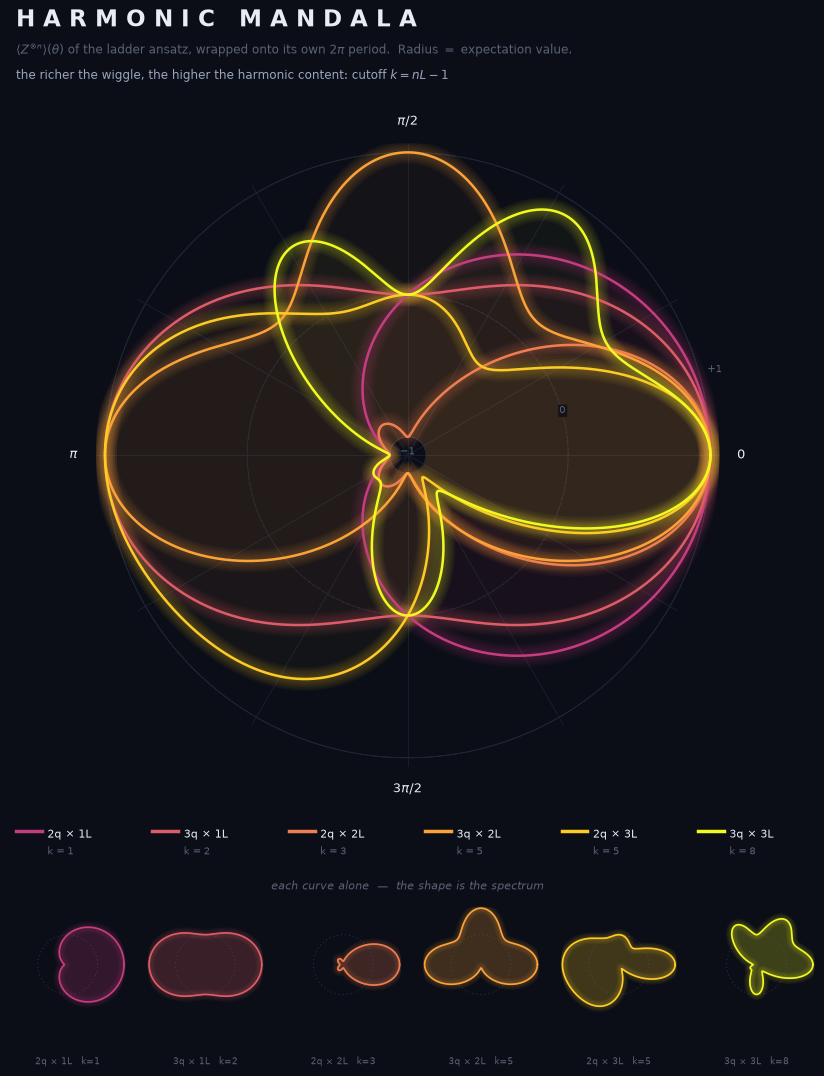

In [4]:
from matplotlib.lines import Line2D

th = np.linspace(0, 2 * np.pi, 4000)
order = [(2, 1), (3, 1), (2, 2), (3, 2), (2, 3), (3, 3)]   # by increasing k
R = lambda y: 0.06 + 0.94 * (y + 1) / 2                     # <Z> in [-1,1] -> r

fig = plt.figure(figsize=(9.6, 11.6))

# ------------------------------------------------------------------ hero
ax = fig.add_axes([0.135, 0.300, 0.73, 0.560], projection="polar")
ax.set_facecolor(LD.BG)

ax.plot(th, np.full_like(th, R(-1)), color=LD.DIM, lw=0.6, alpha=0.45, zorder=1)
ax.plot(th, np.full_like(th, R(0)), color=LD.DIM, lw=0.6, ls=(0, (2, 5)),
        alpha=0.5, zorder=1)
ax.plot(th, np.full_like(th, R(1)), color=LD.DIM, lw=0.6, alpha=0.45, zorder=1)

for cfg in order:
    n, L = cfg
    r = R(LD.curve(th, n, L))
    c = LD.CFG_COLOR[cfg]
    ax.fill_between(th, R(-1), r, color=c, alpha=0.035, lw=0, zorder=2)
    LD.glow(ax, th, r, c, lw=1.9, n=6, alpha=0.045, spread=2.6, zorder=4)

ax.set_ylim(0, 1.03)
ax.set_yticks([R(-1), R(0), R(1)])
ax.set_yticklabels([])
ax.set_xticks(np.deg2rad(np.arange(0, 360, 30)))
ax.set_xticklabels([r"$0$", "", "", r"$\pi/2$", "", "", r"$\pi$", "", "",
                    r"$3\pi/2$", "", ""], fontsize=10, color=LD.FG)
ax.grid(color="#1B2233", lw=0.6)
ax.spines["polar"].set_visible(False)
ax.tick_params(pad=6)

ax.text(np.deg2rad(15), R(-1) - 0.06, r"$-1$", color=LD.DIM, fontsize=7.5, ha="center")
ax.text(np.deg2rad(15), R(0), r"$0$", color=LD.DIM, fontsize=7.5, ha="center",
        bbox=dict(boxstyle="round,pad=0.1", fc=LD.BG, ec="none", alpha=0.8))
ax.text(np.deg2rad(15), R(1) + 0.05, r"$+1$", color=LD.DIM, fontsize=7.5, ha="center")

# ------------------------------------------------------------------ titles
fig.text(0.075, 0.965, "H A R M O N I C   M A N D A L A", fontsize=17,
         color=LD.FG, fontweight="bold")
fig.text(0.075, 0.940,
         r"$\langle Z^{\otimes n}\rangle(\theta)$ of the ladder ansatz, wrapped onto its own "
         r"$2\pi$ period.  Radius $=$ expectation value.",
         fontsize=9, color=LD.DIM)
fig.text(0.075, 0.917, r"the richer the wiggle, the higher the harmonic content: cutoff $k = nL-1$",
         fontsize=9, color="#9AA6BE")

# legend row
for i, cfg in enumerate(order):
    n, L = cfg
    x = 0.075 + i * 0.148
    fig.add_artist(Line2D([x, x + 0.028], [0.242, 0.242],
                          color=LD.CFG_COLOR[cfg], lw=2.6))
    fig.text(x + 0.034, 0.2365, f"{n}q × {L}L", fontsize=8.2, color=LD.FG)
    fig.text(x + 0.034, 0.2215, f"k = {n*L-1}", fontsize=7.2, color=LD.DIM)

# ------------------------------------------------------------------ strip
for i, cfg in enumerate(order):
    n, L = cfg
    a = fig.add_axes([0.068 + i * 0.1495, 0.055, 0.126, 0.135], projection="polar")
    a.set_facecolor(LD.BG)
    r = R(LD.curve(th, n, L))
    c = LD.CFG_COLOR[cfg]
    a.plot(th, np.full_like(th, R(0)), color=LD.DIM, lw=0.5, ls=(0, (2, 4)), alpha=0.5)
    a.fill(th, r, color=c, alpha=0.22, lw=0)
    LD.glow(a, th, r, c, lw=1.3, n=4, alpha=0.05, spread=1.8, zorder=4)
    a.set_ylim(0, 1.03)
    a.set_xticks([]); a.set_yticks([])
    a.spines["polar"].set_visible(False)
    a.grid(False)
    fig.text(0.068 + i * 0.1495 + 0.063, 0.033, f"{n}q × {L}L   k={n*L-1}",
             fontsize=6.8, color=LD.DIM, ha="center")

fig.text(0.5, 0.190, "each curve alone  —  the shape is the spectrum",
         fontsize=8, color=LD.DIM, ha="center", style="italic")

fig.savefig(OUT / "fig1_mandala.png", dpi=200)
plt.show()


## Fig 2 — Spectral Staircase

여기가 물리적으로 제일 깊은 부분. $\langle Z^{\otimes n}\rangle(\theta)$ 는 삼각다항식이고,
회로가 통제하는 건 **모양이 아니라 차수**야.

패널 A 의 흰 상자 가장자리가 정확히 $k_{\max} = nL-1$ 에 놓임.
엄격한 상한 $nL$ (빨간 눈금) 은 절대 도달 못 함 — $Z^{\otimes n}$ 을 마지막 CNOT 사다리로
역전파하면 weight 가 $n-1$ 로 줄어서, 마지막 층이 회전 게이트를 하나 덜 기여하거든.

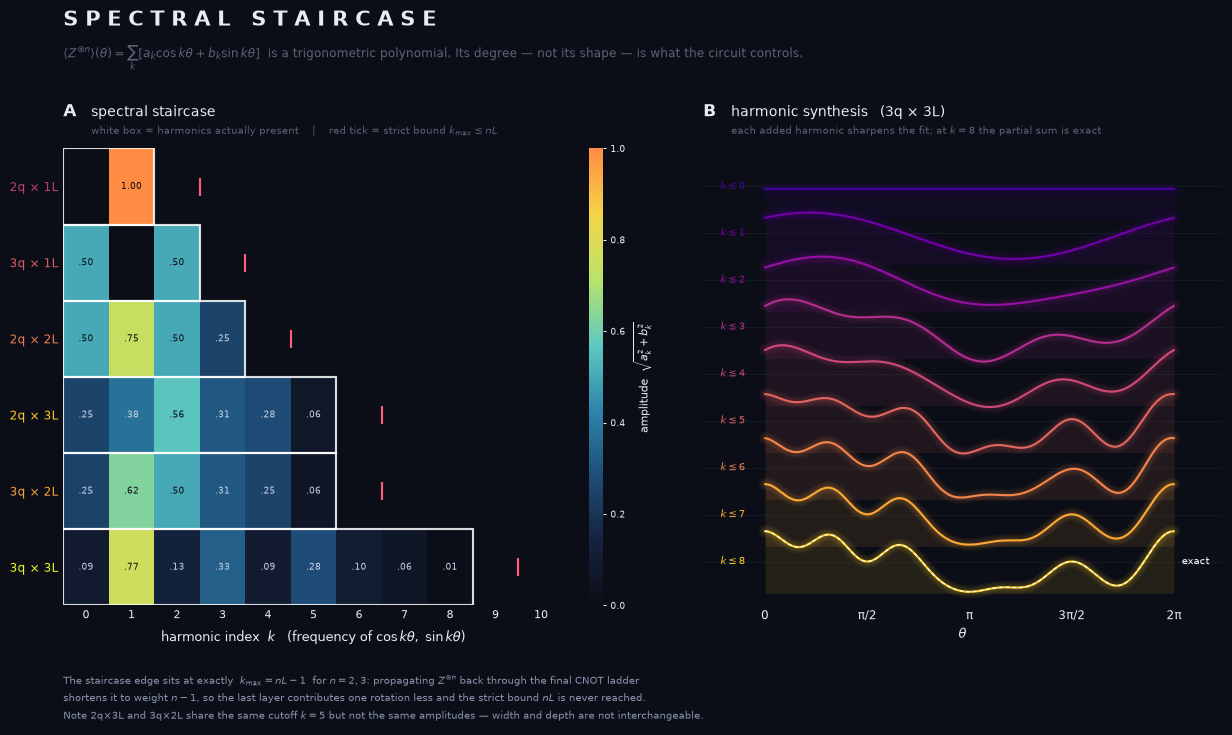

In [5]:
from matplotlib.patches import Rectangle
from matplotlib.colors import LinearSegmentedColormap

th = np.linspace(0, 2 * np.pi, 2000)
order = sorted(LD.CONFIGS, key=lambda c: c[0] * c[1] - 1)      # by cutoff k
KMAX = 10

amps = np.array([LD.fourier(n, L, kmax=KMAX)[2] for n, L in order])

cmap = LinearSegmentedColormap.from_list(
    "deep", ["#0B0E17", "#16233F", "#1F4E79", "#2E86AB", "#5FC9C1",
             "#B9E36A", "#F5D547", "#FF8C42"])

fig = plt.figure(figsize=(13.2, 8.0))

# ============================================================ A: staircase
ax = fig.add_axes([0.055, 0.185, 0.395, 0.595])
im = ax.imshow(amps, cmap=cmap, aspect="auto", vmin=0, vmax=1,
               extent=(-0.5, KMAX + 0.5, len(order) - 0.5, -0.5),
               interpolation="nearest")

for i, (n, L) in enumerate(order):
    k = n * L - 1
    # bright outline enclosing the live harmonics 0..k
    ax.add_patch(Rectangle((-0.5, i - 0.5), k + 1, 1, fill=False,
                           ec="#FFFFFF", lw=1.6, alpha=0.85, zorder=5))
    ax.plot([n * L + 0.5], [i], marker="|", ms=13, mew=1.6,
            color="#FF5C7A", zorder=6)
    for j in range(KMAX + 1):
        v = amps[i, j]
        if v > 1e-6:
            ax.text(j, i, f"{v:.2f}".lstrip("0"), ha="center", va="center",
                    fontsize=6.6, zorder=7,
                    color="#0B0E17" if v > 0.45 else "#C8D2E4")

ax.set_yticks(range(len(order)))
ax.set_yticklabels([f"{n}q × {L}L" for n, L in order], fontsize=9)
for t, (n, L) in zip(ax.get_yticklabels(), order):
    t.set_color(LD.CFG_COLOR[(n, L)])
ax.set_xticks(range(KMAX + 1))
ax.set_xlabel("harmonic index  $k$   (frequency of $\\cos k\\theta,\\ \\sin k\\theta$)",
              fontsize=9.5, labelpad=8)
ax.tick_params(length=0)
for s in ax.spines.values():
    s.set_visible(False)

fig.text(0.055, 0.822, "A", fontsize=13, fontweight="bold", color=LD.FG)
fig.text(0.077, 0.822, "spectral staircase", fontsize=10.5, color=LD.FG)
fig.text(0.077, 0.799,
         "white box = harmonics actually present    |    "
         "red tick = strict bound $k_{\\max}\\leq nL$",
         fontsize=7.8, color=LD.DIM)

cax = fig.add_axes([0.470, 0.185, 0.011, 0.595])
cb = fig.colorbar(im, cax=cax, orientation="vertical")
cb.set_label("amplitude  $\\sqrt{a_k^2+b_k^2}$", fontsize=8, labelpad=6)
cb.outline.set_visible(False)
cb.ax.tick_params(labelsize=7, length=2)

# ============================================================ B: waterfall
ax2 = fig.add_axes([0.560, 0.185, 0.410, 0.595])
n, L = 3, 3
a, b, _ = LD.fourier(n, L, kmax=KMAX)
exact = LD.curve(th, n, L)
ks = np.arange(KMAX + 1)
basis = a[None, :] * np.cos(np.outer(th, ks)) + b[None, :] * np.sin(np.outer(th, ks))

KS = n * L - 1
STEP = 1.55
wcm = plt.get_cmap("plasma")
for K in range(KS + 1):
    S = basis[:, : K + 1].sum(1)
    off = (KS - K) * STEP
    c = wcm(0.12 + 0.78 * K / KS)
    ax2.fill_between(th, off - 1.05, S + off, color=c, alpha=0.10, lw=0)
    LD.glow(ax2, th, S + off, c, lw=1.6, n=4, alpha=0.05, spread=2.0, zorder=3)
    ax2.axhline(off, color=LD.DIM, lw=0.4, alpha=0.25, zorder=1)
    ax2.text(-0.30, off, f"$k\\leq{K}$", fontsize=7.6, color=c,
             ha="right", va="center")

ax2.plot(th, exact, color="#FFFFFF", lw=1.0, ls=(0, (3, 2)), alpha=0.9, zorder=6)
ax2.text(2 * np.pi + 0.12, 0, "exact", fontsize=7.6, color="#FFFFFF",
         va="center", ha="left")

ax2.set_xlim(-0.95, 2 * np.pi + 0.75)
ax2.set_ylim(-1.45, KS * STEP + 1.25)
ax2.set_xticks([0, np.pi / 2, np.pi, 3 * np.pi / 2, 2 * np.pi])
ax2.set_xticklabels(["0", "π/2", "π", "3π/2", "2π"], fontsize=9)
ax2.set_yticks([])
ax2.set_xlabel(r"$\theta$", fontsize=10)
for s in ax2.spines.values():
    s.set_visible(False)
ax2.tick_params(length=0)

fig.text(0.560, 0.822, "B", fontsize=13, fontweight="bold", color=LD.FG)
fig.text(0.582, 0.822, "harmonic synthesis   (3q × 3L)", fontsize=10.5, color=LD.FG)
fig.text(0.582, 0.799,
         "each added harmonic sharpens the fit; at $k=8$ the partial sum is exact",
         fontsize=7.8, color=LD.DIM)

fig.text(0.055, 0.940, "S P E C T R A L   S T A I R C A S E", fontsize=16,
         color=LD.FG, fontweight="bold")
fig.text(0.055, 0.898,
         r"$\langle Z^{\otimes n}\rangle(\theta)=\sum_k\left[a_k\cos k\theta+b_k\sin k\theta\right]$"
         r"  is a trigonometric polynomial. Its degree — not its shape — is what the circuit controls.",
         fontsize=9.2, color=LD.DIM)

fig.text(0.055, 0.098,
         "The staircase edge sits at exactly  $k_{\\max}=nL-1$  for $n=2,3$: propagating $Z^{\\otimes n}$ back through the final CNOT ladder\n"
         "shortens it to weight $n-1$, so the last layer contributes one rotation less and the strict bound $nL$ is never reached.\n"
         "Note 2q×3L and 3q×2L share the same cutoff $k=5$ but not the same amplitudes — width and depth are not interchangeable.",
         fontsize=7.6, color="#8894AC", linespacing=1.75, va="top")

fig.savefig(OUT / "fig2_spectrum.png", dpi=200)
plt.show()


## Fig 3 — Parity River

$\langle Z^{\otimes n}\rangle = P_{\rm even} - P_{\rm odd}$ 의 그림 증명.
짝수 패리티(1의 개수가 짝수) 기저상태는 0 에서 위로, 홀수는 아래로 쌓음.
흰 선이 순 불균형이고, 그게 곧 관측값. 셀 안에 `assert` 로 항등식을 박아뒀어.

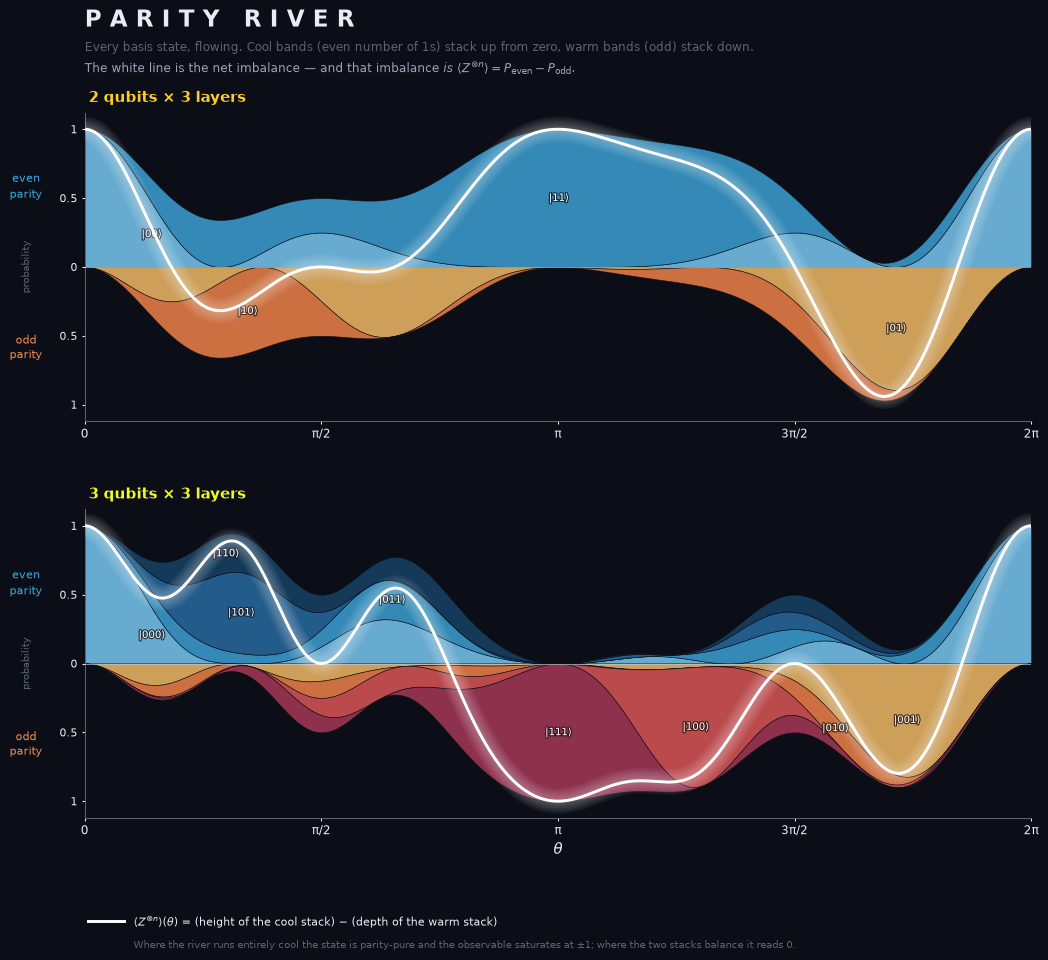

In [6]:
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D

th = np.linspace(0, 2 * np.pi, 1600)

EVEN = ["#7FD4FF", "#3FA9E0", "#2A6FA8", "#17456B"]   # cool  -> +1
ODD = ["#FFC46B", "#FF8A4C", "#E85A5A", "#B03A5B"]    # warm  -> -1

fig = plt.figure(figsize=(12.4, 10.2))
panels = [(2, 3), (3, 3)]

for pi, (n, L) in enumerate(panels):
    ax = fig.add_axes([0.075, 0.560 - pi * 0.405, 0.795, 0.315])
    P = LD.probs(th, n, L)                     # (2**n, T)
    sgn = LD.parity_signs(n)
    ev = [i for i in range(2 ** n) if sgn[i] > 0]
    od = [i for i in range(2 ** n) if sgn[i] < 0]

    # even parity stacks upward from 0, odd parity stacks downward
    base = np.zeros_like(th)
    for j, i in enumerate(ev):
        top = base + P[i]
        ax.fill_between(th, base, top, color=EVEN[j % len(EVEN)],
                        alpha=0.80, lw=0.5, ec=LD.BG)
        lo, hi = int(0.07 * len(th)), int(0.93 * len(th))
        mid = lo + int(np.argmax(P[i][lo:hi]))
        if P[i][mid] > 0.13:
            ax.text(th[mid], (base[mid] + top[mid]) / 2,
                    "|" + format(i, f"0{n}b") + "⟩", fontsize=7.6,
                    color="#FFFFFF", ha="center", va="center", zorder=6,
                    path_effects=[pe.withStroke(linewidth=1.8, foreground="#0A0E18", alpha=0.75)])
        base = top
    Pe = base.copy()

    base = np.zeros_like(th)
    for j, i in enumerate(od):
        top = base - P[i]
        ax.fill_between(th, base, top, color=ODD[j % len(ODD)],
                        alpha=0.80, lw=0.5, ec=LD.BG)
        lo, hi = int(0.07 * len(th)), int(0.93 * len(th))
        mid = lo + int(np.argmax(P[i][lo:hi]))
        if P[i][mid] > 0.13:
            ax.text(th[mid], (base[mid] + top[mid]) / 2,
                    "|" + format(i, f"0{n}b") + "⟩", fontsize=7.6,
                    color="#FFFFFF", ha="center", va="center", zorder=6,
                    path_effects=[pe.withStroke(linewidth=1.8, foreground="#160A08", alpha=0.75)])
        base = top
    Po = -base.copy()

    y = LD.curve(th, n, L)
    assert np.max(np.abs((Pe - Po) - y)) < 1e-12       # the identity, checked
    LD.glow(ax, th, y, "#FFFFFF", lw=2.2, n=6, alpha=0.05, spread=2.8, zorder=8)
    ax.axhline(0, color=LD.FG, lw=0.7, alpha=0.6, zorder=7)

    ax.set_xlim(0, 2 * np.pi)
    ax.set_ylim(-1.12, 1.12)
    ax.set_xticks([0, np.pi / 2, np.pi, 3 * np.pi / 2, 2 * np.pi])
    ax.set_xticklabels(["0", "π/2", "π", "3π/2", "2π"], fontsize=9)
    ax.set_yticks([-1, -0.5, 0, 0.5, 1])
    ax.set_yticklabels(["1", "0.5", "0", "0.5", "1"], fontsize=8)
    ax.tick_params(length=2)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    ax.spines["left"].set_color(LD.DIM)
    ax.spines["bottom"].set_color(LD.DIM)
    if pi == len(panels) - 1:
        ax.set_xlabel(r"$\theta$", fontsize=11)

    ax.text(0.004, 1.035, f"{n} qubits × {L} layers", transform=ax.transAxes,
            fontsize=11, color=LD.CFG_COLOR[(n, L)], fontweight="bold")
    ax.text(-0.062, 0.76, "even\nparity", transform=ax.transAxes, fontsize=8,
            color=EVEN[1], ha="center", va="center", linespacing=1.5)
    ax.text(-0.062, 0.24, "odd\nparity", transform=ax.transAxes, fontsize=8,
            color=ODD[1], ha="center", va="center", linespacing=1.5)
    ax.text(-0.062, 0.5, "probability", transform=ax.transAxes, fontsize=7.5,
            color=LD.DIM, ha="center", va="center", rotation=90)

fig.text(0.075, 0.963, "P A R I T Y   R I V E R", fontsize=17,
         color=LD.FG, fontweight="bold")
fig.text(0.075, 0.938,
         r"Every basis state, flowing. Cool bands (even number of 1s) stack up from zero, "
         r"warm bands (odd) stack down.",
         fontsize=9.2, color=LD.DIM)
fig.text(0.075, 0.916,
         r"The white line is the net imbalance — and that imbalance $\it{is}$ "
         r"$\langle Z^{\otimes n}\rangle = P_{\rm even}-P_{\rm odd}$.",
         fontsize=9.2, color="#9AA6BE")

fig.add_artist(Line2D([0.078, 0.108], [0.050, 0.050], color="#FFFFFF", lw=2.2))
fig.text(0.116, 0.0445, r"$\langle Z^{\otimes n}\rangle(\theta)$ = (height of the cool stack) − (depth of the warm stack)",
         fontsize=8.4, color=LD.FG)
fig.text(0.116, 0.022,
         "Where the river runs entirely cool the state is parity-pure and the observable saturates at ±1; "
         "where the two stacks balance it reads 0.",
         fontsize=7.6, color=LD.DIM)

fig.savefig(OUT / "fig3_river.png", dpi=200)
plt.show()


## Fig 4 — The Diagonal You Were Looking At

⚠️ 이 셀은 141×141 statevector 를 두 번 돌려서 **20~30초** 걸림.
빠르게 보려면 `N = 141` 을 `N = 81` 로 낮춰.

깊이 $L$ 짜리 안사츠는 각도가 $L$ 개인데, 전부 하나의 $\theta$ 로 묶으면
지형을 탐색하는 게 아니라 **닫힌 경로 하나**를 따라 걷는 거야.
여기선 그 대각선이 전역 최소 $-1$ 에 실제로 도달해서 성능 손해는 없지만,
곡률·골짜기 폭·gradient 방향 같은 기하는 전부 접혀서 사라져.

(2,2)  grid min -1.0000   diagonal min -1.0000
(3,2)  grid min -1.0000   diagonal min -1.0000


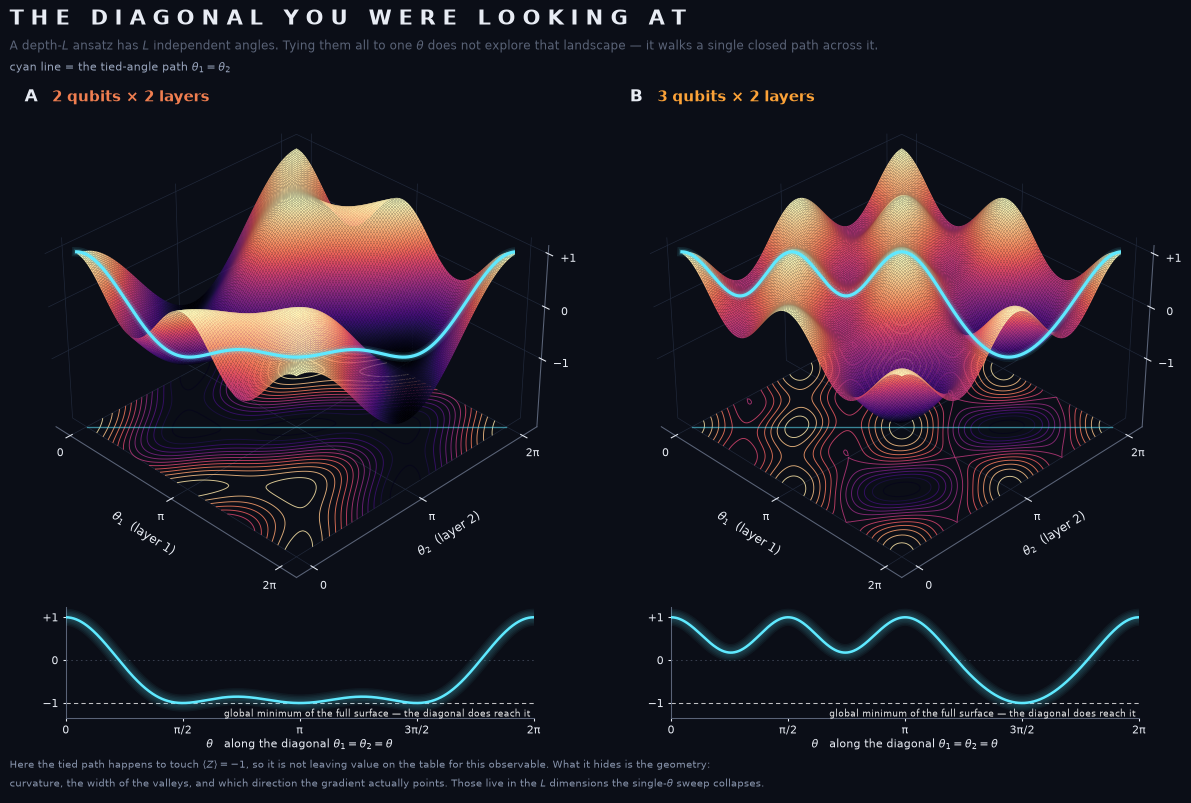

In [7]:
from matplotlib.colors import Normalize

N = 141
g = np.linspace(0, 2 * np.pi, N)
T1, T2 = np.meshgrid(g, g, indexing="ij")
th = np.linspace(0, 2 * np.pi, 900)

CFGS = [(2, 2), (3, 2)]
DATA = {}
for n, L in CFGS:
    E = np.array([[LD.expZ(0, n, L, thetas=(a, b)) for b in g] for a in g])
    DATA[(n, L)] = E
    d = np.array([LD.expZ(t, n, L) for t in th])
    print(f"({n},{L})  grid min {E.min():+.4f}   diagonal min {d.min():+.4f}")

fig = plt.figure(figsize=(13.0, 8.6))

for i, cfg in enumerate(CFGS):
    n, L = cfg
    E = DATA[cfg]
    x0 = 0.035 + i * 0.485

    # ------------------------------------------------ 3D surface
    ax = fig.add_axes([x0, 0.295, 0.45, 0.545], projection="3d")
    ax.set_facecolor(LD.BG)
    for pane in (ax.xaxis, ax.yaxis, ax.zaxis):
        pane.set_pane_color((0.043, 0.055, 0.09, 1.0))
        pane._axinfo["grid"]["color"] = (0.13, 0.16, 0.23, 1.0)
        pane._axinfo["grid"]["linewidth"] = 0.5

    ax.plot_surface(T1, T2, E, cmap="magma", norm=Normalize(-1, 1),
                    rcount=N, ccount=N, linewidth=0, antialiased=True,
                    alpha=0.97, shade=True, zorder=2)
    ax.contour(T1, T2, E, levels=14, zdir="z", offset=-2.35,
               cmap="magma", norm=Normalize(-1, 1), linewidths=0.7, alpha=0.85)

    # the tied-angle diagonal, lifted just off the surface so it reads
    d = np.array([LD.expZ(t, n, L) for t in th])
    for w, al in [(7.0, 0.10), (4.5, 0.16), (2.4, 1.0)]:
        ax.plot(th, th, d + 0.035, color="#5FE9FF", lw=w, alpha=al, zorder=12)
    ax.plot(th, th, np.full_like(th, -2.35), color="#5FE9FF", lw=1.0,
            alpha=0.55, zorder=6)

    ax.set_zlim(-2.35, 1.15)
    tk = [0, np.pi, 2 * np.pi]
    tl = ["0", "π", "2π"]
    ax.set_xticks(tk); ax.set_xticklabels(tl, fontsize=8)
    ax.set_yticks(tk); ax.set_yticklabels(tl, fontsize=8)
    ax.set_zticks([-1, 0, 1]); ax.set_zticklabels(["−1", "0", "+1"], fontsize=8)
    ax.set_xlabel(r"$\theta_1$  (layer 1)", fontsize=9, labelpad=-2)
    ax.set_ylabel(r"$\theta_2$  (layer 2)", fontsize=9, labelpad=-2)
    ax.view_init(elev=33, azim=-45)
    ax.tick_params(pad=-1, colors=LD.FG)
    try:
        ax.set_box_aspect((1, 1, 0.62), zoom=1.16)
    except Exception:
        pass

    fig.text(x0 + 0.012, 0.862, "AB"[i], fontsize=13, fontweight="bold", color=LD.FG)
    fig.text(x0 + 0.034, 0.862, f"{n} qubits × 2 layers",
             fontsize=11, color=LD.CFG_COLOR[cfg], fontweight="bold")

    # ------------------------------------------------ diagonal read-out
    a2 = fig.add_axes([x0 + 0.045, 0.115, 0.375, 0.135])
    LD.glow(a2, th, d, "#5FE9FF", lw=1.9, n=5, alpha=0.05, spread=2.2, zorder=4)
    a2.axhline(0, color=LD.DIM, lw=0.6, ls=(0, (2, 4)), alpha=0.7)
    a2.axhline(E.min(), color="#FFFFFF", lw=0.8, ls=(0, (4, 3)), alpha=0.75)
    a2.text(2 * np.pi, E.min() - 0.13, "global minimum of the full surface — the diagonal does reach it ",
            fontsize=6.8, color="#FFFFFF", ha="right", va="top", alpha=0.9)
    a2.set_xlim(0, 2 * np.pi); a2.set_ylim(-1.35, 1.25)
    a2.set_xticks([0, np.pi / 2, np.pi, 3 * np.pi / 2, 2 * np.pi])
    a2.set_xticklabels(["0", "π/2", "π", "3π/2", "2π"], fontsize=8)
    a2.set_yticks([-1, 0, 1]); a2.set_yticklabels(["−1", "0", "+1"], fontsize=8)
    a2.set_xlabel(r"$\theta$   along the diagonal $\theta_1=\theta_2=\theta$",
                  fontsize=8.5, labelpad=2)
    for s in ("top", "right"):
        a2.spines[s].set_visible(False)
    a2.spines["left"].set_color(LD.DIM); a2.spines["bottom"].set_color(LD.DIM)
    a2.tick_params(length=2)

fig.text(0.035, 0.955, "T H E   D I A G O N A L   Y O U   W E R E   L O O K I N G   A T",
         fontsize=15.5, color=LD.FG, fontweight="bold")
fig.text(0.035, 0.924,
         r"A depth-$L$ ansatz has $L$ independent angles. Tying them all to one $\theta$ does not explore that landscape — "
         r"it walks a single closed path across it.",
         fontsize=9.2, color=LD.DIM)
fig.text(0.035, 0.899,
         "cyan line = the tied-angle path $\\theta_1=\\theta_2$",
         fontsize=8.6, color="#9AA6BE")

fig.text(0.035, 0.032,
         "Here the tied path happens to touch $\\langle Z\\rangle=-1$, so it is not leaving value on the table for this observable. What it hides is the geometry:\n"
         "curvature, the width of the valleys, and which direction the gradient actually points. Those live in the $L$ dimensions the single-$\\theta$ sweep collapses.",
         fontsize=7.8, color="#8894AC", linespacing=1.8)

fig.savefig(OUT / "fig4_landscape.png", dpi=190)
plt.show()


## Fig 5 — The Bloch Disk

`Ry`, `CNOT`, $|0\rangle^{\otimes n}$ 이 전부 실수라 상태벡터가 $\mathbb{R}^{2^n}$ 을 절대
안 벗어나. 따라서 축소 밀도행렬이 실대칭이고 $\langle Y\rangle \equiv 0$ —
$\theta$ 스윕 전체가 Bloch 구의 **단 하나의 대원 디스크**에 갇혀.

반지름이 전부야. $|\vec r| = 1$ 이면 그 큐빗은 순수·곱 상태, $|\vec r| \to 0$ 이면
나머지 레지스터와 최대로 얽힌 상태.

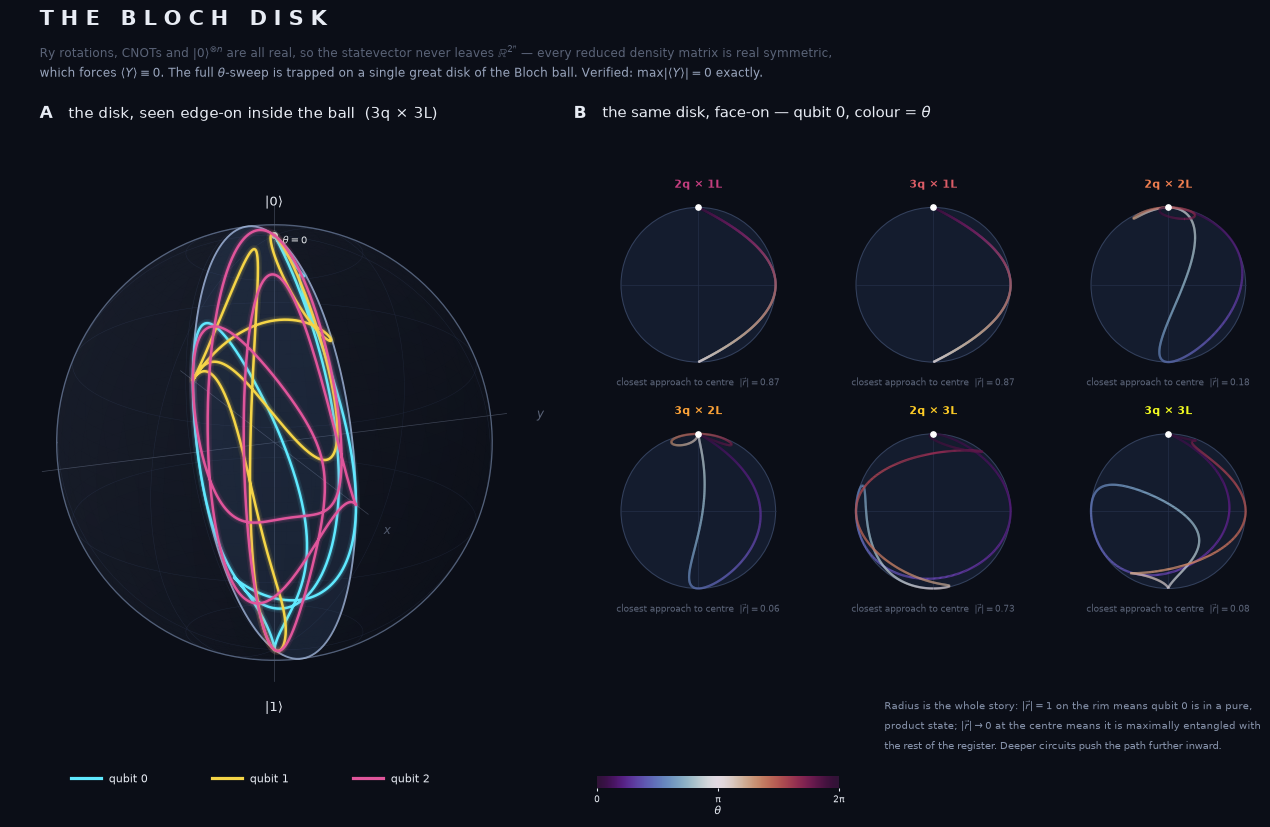

In [8]:
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

th = np.linspace(0, 2 * np.pi, 1400)
order = [(2, 1), (3, 1), (2, 2), (3, 2), (2, 3), (3, 3)]
QC = ["#5FE9FF", "#F5D547", "#E0559B"]

fig = plt.figure(figsize=(13.6, 8.8))

# =========================================================== A : Bloch hero
ax = fig.add_axes([0.005, 0.085, 0.395, 0.735], projection="3d")
ax.set_facecolor(LD.BG)
ax.set_axis_off()
ax.set_proj_type("ortho")

u = np.linspace(0, 2 * np.pi, 90)
v = np.linspace(0, np.pi, 46)
xs = np.outer(np.cos(u), np.sin(v))
ys = np.outer(np.sin(u), np.sin(v))
zs = np.outer(np.ones_like(u), np.cos(v))
ax.plot_surface(xs, ys, zs, color="#5C6B8A", alpha=0.085, linewidth=0,
                antialiased=True, zorder=1)
for k in range(0, 90, 15):
    ax.plot(xs[k], ys[k], zs[k], color="#2A3550",
            lw=0.35, alpha=0.5, zorder=1)
for k in range(6, 46, 11):
    ax.plot(xs[:, k], ys[:, k], zs[:, k], color="#2A3550", lw=0.35, alpha=0.5, zorder=1)

# the x-z great disk: every reduced state of this ansatz lives here
c = np.linspace(0, 2 * np.pi, 300)
ax.plot(np.cos(c), np.zeros_like(c), np.sin(c), color="#A8BBDD", lw=1.4, alpha=0.95, zorder=3)
tri = np.stack([np.cos(c), np.zeros_like(c), np.sin(c)], axis=1)
ax.add_collection3d(Poly3DCollection([tri], facecolor="#4A6FA5",
                                               alpha=0.20, edgecolor="none", zorder=2))
for a, b, lab in [((0, 0, 1.14), None, r"$|0\rangle$"), ((0, 0, -1.30), None, r"$|1\rangle$")]:
    ax.text(*a, lab, color=LD.FG, fontsize=10, ha="center")
ax.plot([-1.15, 1.15], [0, 0], [0, 0], color=LD.DIM, lw=0.5, alpha=0.7)
ax.plot([0, 0], [-1.15, 1.15], [0, 0], color=LD.DIM, lw=0.5, alpha=0.7)
ax.plot([0, 0], [0, 0], [-1.15, 1.15], color=LD.DIM, lw=0.5, alpha=0.7)
ax.text(1.34, 0, -0.04, r"$x$", color=LD.DIM, fontsize=9)
ax.text(0, 1.30, -0.04, r"$y$", color=LD.DIM, fontsize=9)

# silhouette of the ball as seen from this camera (great circle _|_ view axis)
_el, _az = np.deg2rad(18), np.deg2rad(-22)
_d = np.array([np.cos(_el) * np.cos(_az), np.cos(_el) * np.sin(_az), np.sin(_el)])
_e1 = np.cross(_d, [0, 0, 1.0]); _e1 /= np.linalg.norm(_e1)
_e2 = np.cross(_d, _e1)
_sil = np.outer(np.cos(c), _e1) + np.outer(np.sin(c), _e2)
ax.plot(_sil[:, 0], _sil[:, 1], _sil[:, 2], color="#6E7F9E", lw=1.0,
        alpha=0.75, zorder=1)

n, L = 3, 3
for q in range(n):
    b = LD.rdm_bloch(th, n, L, q)
    for w, al in [(6.0, 0.09), (3.6, 0.15), (1.9, 1.0)]:
        ax.plot(b[:, 0], b[:, 1], b[:, 2], color=QC[q], lw=w, alpha=al, zorder=10 + q)
ax.scatter([0], [0], [1], s=36, color="#FFFFFF", edgecolor=LD.BG, lw=0.8,
           zorder=20, depthshade=False)
ax.text(0.10, 0, 0.99, r"$\theta=0$", color="#FFFFFF", fontsize=7.5)

ax.set_xlim(-1.0, 1.0); ax.set_ylim(-1.0, 1.0); ax.set_zlim(-1.0, 1.0)
ax.view_init(elev=18, azim=-22)
try:
    ax.set_box_aspect((1, 1, 1), zoom=1.42)
except Exception:
    pass

fig.text(0.028, 0.845, "A", fontsize=13, fontweight="bold", color=LD.FG)
fig.text(0.050, 0.845, "the disk, seen edge-on inside the ball  (3q × 3L)", fontsize=11, color=LD.FG)
for q in range(3):
    fig.add_artist(Line2D([0.052 + q * 0.108, 0.075 + q * 0.108], [0.064, 0.064],
                          color=QC[q], lw=2.4))
    fig.text(0.081 + q * 0.108, 0.0585, f"qubit {q}", fontsize=8.2, color=LD.FG)

# =========================================================== B : face-on disks
cyc = plt.get_cmap("twilight_shifted")
for i, cfg in enumerate(order):
    n, L = cfg
    r, cidx = divmod(i, 3)
    a = fig.add_axes([0.455 + cidx * 0.180, 0.545 - r * 0.268, 0.155, 0.205])
    a.set_facecolor(LD.BG)
    a.add_patch(plt.Circle((0, 0), 1, fc="#141C2E", ec="#33405C", lw=0.8, zorder=0))
    a.plot([-1, 1], [0, 0], color="#26314A", lw=0.5, zorder=1)
    a.plot([0, 0], [-1, 1], color="#26314A", lw=0.5, zorder=1)

    b = LD.rdm_bloch(th, n, L, 0)
    pts = np.array([b[:, 0], b[:, 2]]).T.reshape(-1, 1, 2)
    segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
    lc = LineCollection(segs, cmap=cyc, norm=Normalize(0, 2 * np.pi),
                        linewidths=1.7, zorder=4)
    lc.set_array(th[:-1])
    a.add_collection(lc)
    a.scatter([0], [1], s=16, color="#FFFFFF", zorder=6)

    a.set_xlim(-1.12, 1.12); a.set_ylim(-1.12, 1.12)
    a.set_aspect("equal"); a.set_xticks([]); a.set_yticks([])
    for s in a.spines.values():
        s.set_visible(False)
    a.text(0, 1.22, f"{n}q × {L}L", fontsize=8.6, color=LD.CFG_COLOR[cfg],
           ha="center", va="bottom", fontweight="bold")
    rmin = np.linalg.norm(b, axis=1).min()
    a.text(0, -1.20, f"closest approach to centre  $|\\vec r|={rmin:.2f}$",
           fontsize=6.6, color=LD.DIM, ha="center", va="top")

fig.text(0.437, 0.845, "B", fontsize=13, fontweight="bold", color=LD.FG)
fig.text(0.459, 0.845, "the same disk, face-on — qubit 0, colour = $\\theta$",
         fontsize=11, color=LD.FG)

sm = plt.cm.ScalarMappable(cmap=cyc, norm=Normalize(0, 2 * np.pi))
cax = fig.add_axes([0.455, 0.052, 0.185, 0.014])
cb = fig.colorbar(sm, cax=cax, orientation="horizontal")
cb.set_ticks([0, np.pi, 2 * np.pi]); cb.set_ticklabels(["0", "π", "2π"])
cb.ax.tick_params(labelsize=7, length=2)
cb.outline.set_visible(False)
cb.set_label(r"$\theta$", fontsize=8, labelpad=1)

fig.text(0.675, 0.098,
         "Radius is the whole story: $|\\vec r|=1$ on the rim means qubit 0 is in a pure,\n"
         "product state; $|\\vec r|\\to 0$ at the centre means it is maximally entangled with\n"
         "the rest of the register. Deeper circuits push the path further inward.",
         fontsize=7.8, color="#8894AC", linespacing=1.9)

fig.text(0.028, 0.955, "T H E   B L O C H   D I S K", fontsize=16,
         color=LD.FG, fontweight="bold")
fig.text(0.028, 0.917,
         r"Ry rotations, CNOTs and $|0\rangle^{\otimes n}$ are all real, so the statevector never leaves "
         r"$\mathbb{R}^{2^n}$ — every reduced density matrix is real symmetric,",
         fontsize=9.2, color=LD.DIM)
fig.text(0.028, 0.893,
         r"which forces $\langle Y\rangle \equiv 0$. The full $\theta$-sweep is trapped on a single "
         r"great disk of the Bloch ball. Verified: $\max|\langle Y\rangle| = 0$ exactly.",
         fontsize=9.2, color="#9AA6BE")

fig.savefig(OUT / "fig5_bloch.png", dpi=190)
plt.show()


## 자체 평가 (C1–C9)

그림에 인쇄한 주장은 전부 여기서 테스트로 검증돼. C7 은 문장 하나당 체크 하나.

In [9]:
"""Self-evaluation for the ladder-ansatz figure set.

C1 simulator reproduces independently hand-derived analytic curves
C2 Fourier decomposition reconstructs the curve to machine precision
C3 stated cutoff law k_max = nL-1 holds for every plotted config
C4 parity identity <Z^n> = P_even - P_odd holds pointwise      (Fig 3 premise)
C5 landscape diagonal E(t,t) equals the 1-D curve              (Fig 4 premise)
C6 Bloch trajectories satisfy <Y> = 0 and |r| <= 1             (Fig 5 premise)
C7 each individual claim printed on a figure is true
C8 palette stays distinguishable under deuteranopia + protanopia
C9 all five PNGs exist and are non-trivial
"""
import os
import numpy as np

R = []
def check(cid, name, ok, detail=""):
    R.append((cid, name, bool(ok), detail))

th = np.linspace(0, 2 * np.pi, 4001)

# ---- C1 analytic ground truth (derived by hand, independent of the simulator)
e = max(np.max(np.abs(LD.curve(th, 2, 1) - np.cos(th))),
        np.max(np.abs(LD.curve(th, 3, 1) - np.cos(th) ** 2)),
        np.max(np.abs(LD.curve(th, 2, 2) - (np.cos(th) ** 3 - np.sin(th) ** 2))))
check("C1", "matches hand-derived analytic curves", e < 1e-12, f"max err {e:.2e}")

# ---- C2 Fourier reconstruction
worst = 0.0
for n, L in LD.CONFIGS:
    a, b, _ = LD.fourier(n, L, kmax=24)
    ks = np.arange(len(a))
    rec = (a * np.cos(np.outer(th, ks)) + b * np.sin(np.outer(th, ks))).sum(1)
    worst = max(worst, np.max(np.abs(rec - LD.curve(th, n, L))))
check("C2", "Fourier series reconstructs curve", worst < 1e-12, f"max err {worst:.2e}")

# ---- C3 cutoff law
bad = []
for n, L in LD.CONFIGS:
    amp = LD.fourier(n, L, kmax=24)[2]
    k = int(np.max(np.nonzero(amp > 1e-9)[0]))
    if k != n * L - 1:
        bad.append((n, L, k))
check("C3", "k_max = nL-1 for all six configs", not bad, f"violations: {bad}")

# ---- C4 parity identity
worst = 0.0
for n, L in [(2, 3), (3, 3)]:
    P = LD.probs(th[::4], n, L)
    s = LD.parity_signs(n)
    net = (P[s > 0].sum(0)) - (P[s < 0].sum(0))
    worst = max(worst, np.max(np.abs(net - LD.curve(th[::4], n, L))))
check("C4", "<Z^n> = P_even - P_odd pointwise", worst < 1e-12, f"max err {worst:.2e}")

# ---- C5 landscape diagonal
worst = 0.0
for n, L in [(2, 2), (3, 2)]:
    d1 = np.array([LD.expZ(0, n, L, thetas=(t, t)) for t in th[::40]])
    worst = max(worst, np.max(np.abs(d1 - LD.curve(th[::40], n, L))))
check("C5", "landscape diagonal == plotted 1-D curve", worst < 1e-12, f"max err {worst:.2e}")

# ---- C6 Bloch
ymax, rmax = 0.0, 0.0
for n, L in LD.CONFIGS:
    for q in range(n):
        bb = LD.rdm_bloch(th[::8], n, L, q)
        ymax = max(ymax, np.max(np.abs(bb[:, 1])))
        rmax = max(rmax, np.max(np.linalg.norm(bb, axis=1)))
check("C6", "<Y> = 0 and |r| <= 1 everywhere", ymax == 0.0 and rmax <= 1 + 1e-12,
      f"max|<Y>| {ymax:.1e}, max|r| {rmax:.6f}")

# ---- C7 individual printed claims
claims = {}
# Fig2: strict bound nL is never reached, for n=2,3
claims["strict bound nL never reached (n=2,3)"] = all(
    int(np.max(np.nonzero(LD.fourier(n, L, kmax=24)[2] > 1e-9)[0])) < n * L
    for n, L in LD.CONFIGS)
# Fig2: 2q3L and 3q2L share cutoff 5 but differ in amplitudes
A = LD.fourier(2, 3, kmax=6)[2]; B = LD.fourier(3, 2, kmax=6)[2]
claims["2q3L and 3q2L: same cutoff, different amplitudes"] = (
    int(np.max(np.nonzero(A > 1e-9)[0])) == int(np.max(np.nonzero(B > 1e-9)[0])) == 5
    and np.max(np.abs(A - B)) > 0.05)
# Fig2: back-propagated Z^n through the CNOT ladder has weight n-1 for n=2,3
def ladder_weight(n):
    P = np.ones(n, dtype=int)                      # 1 = Z present
    for q in range(n - 2, -1, -1):                 # undo CNOT(q,q+1), reverse order
        if P[q + 1]:
            P[q] ^= 1
    return int(P.sum())
claims["ladder-conjugated Z^n has weight n-1 (n=2,3)"] = all(
    ladder_weight(n) == n - 1 for n in (2, 3))
# Fig4: tied-angle diagonal does reach the global minimum of the 2-D surface
g = np.linspace(0, 2 * np.pi, 121)
ok4 = True
for n, L in [(2, 2), (3, 2)]:
    E = np.array([[LD.expZ(0, n, L, thetas=(x, y)) for y in g] for x in g])
    ok4 &= abs(E.min() - LD.curve(th, n, L).min()) < 1e-6
claims["tied diagonal reaches the global minimum"] = ok4
# Fig1: curves are even in theta only for (2,1),(3,1),(2,2)
ev = {c for c in LD.CONFIGS if np.max(np.abs(LD.fourier(*c, kmax=24)[1])) < 1e-9}
claims["only (2,1),(3,1),(2,2) are even in theta"] = ev == {(2, 1), (3, 1), (2, 2)}
# Fig5: deeper circuits push closer to the Bloch centre (3 layers vs 1 layer)
claims["depth pushes qubit 0 further toward the centre"] = all(
    np.linalg.norm(LD.rdm_bloch(th[::8], n, 3, 0), axis=1).min()
    < np.linalg.norm(LD.rdm_bloch(th[::8], n, 1, 0), axis=1).min() for n in (2, 3))
check("C7", "every printed claim verified", all(claims.values()),
      "; ".join(f"{k}={'OK' if v else 'FAIL'}" for k, v in claims.items()))

# ---- C8 colour-vision safety (Machado et al. style linear CVD approximation)
def hex2rgb(h):
    return np.array([int(h[i:i + 2], 16) for i in (1, 3, 5)]) / 255.0
DEUT = np.array([[0.367, 0.861, -0.228], [0.280, 0.673, 0.047], [-0.012, 0.043, 0.969]])
PROT = np.array([[0.153, 1.053, -0.206], [0.115, 0.786, 0.099], [-0.004, -0.048, 1.052]])
def lab(rgb):
    r, g_, b = np.clip(rgb, 0, 1)
    return np.array([0.2126 * r + 0.7152 * g_ + 0.0722 * b, r - g_, g_ - b])
cols = [hex2rgb(LD.CFG_COLOR[c]) for c in LD.CONFIGS]
mind = {}
for nm, M in [("normal", np.eye(3)), ("deuteranopia", DEUT), ("protanopia", PROT)]:
    pts = [lab(M @ c) for c in cols]
    mind[nm] = min(np.linalg.norm(pts[i] - pts[j])
                   for i in range(len(pts)) for j in range(i + 1, len(pts)))
check("C8", "palette separable under CVD", min(mind.values()) > 0.10,
      "  ".join(f"{k}: min sep {v:.3f}" for k, v in mind.items()))

# ---- C9 outputs
files = ["fig1_mandala.png", "fig2_spectrum.png", "fig3_river.png",
         "fig4_landscape.png", "fig5_bloch.png"]
sizes = {f: (OUT / f).stat().st_size // 1024 for f in files if (OUT / f).exists()}
check("C9", "all five figures rendered", len(sizes) == 5 and min(sizes.values()) > 150,
      "  ".join(f"{f.split('_')[0]}:{s}KB" for f, s in sizes.items()))

# ---------------------------------------------------------------- report
w = max(len(n) for _, n, _, _ in R)
print("=" * (w + 34))
for cid, name, ok, det in R:
    print(f"{cid}  {'PASS' if ok else 'FAIL'}  {name:<{w}}  {det}")
print("=" * (w + 34))
print(f"{sum(o for _, _, o, _ in R)}/{len(R)} criteria passed")


C1  PASS  matches hand-derived analytic curves     max err 1.22e-15
C2  PASS  Fourier series reconstructs curve        max err 2.33e-15
C3  PASS  k_max = nL-1 for all six configs         violations: []
C4  PASS  <Z^n> = P_even - P_odd pointwise         max err 2.22e-16
C5  PASS  landscape diagonal == plotted 1-D curve  max err 0.00e+00
C6  PASS  <Y> = 0 and |r| <= 1 everywhere          max|<Y>| 0.0e+00, max|r| 1.000000
C7  PASS  every printed claim verified             strict bound nL never reached (n=2,3)=OK; 2q3L and 3q2L: same cutoff, different amplitudes=OK; ladder-conjugated Z^n has weight n-1 (n=2,3)=OK; tied diagonal reaches the global minimum=OK; only (2,1),(3,1),(2,2) are even in theta=OK; depth pushes qubit 0 further toward the centre=OK
C8  PASS  palette separable under CVD              normal: min sep 0.239  deuteranopia: min sep 0.175  protanopia: min sep 0.214
C9  PASS  all five figures rendered                fig1:797KB  fig2:449KB  fig3:629KB  fig4:1512KB  fig5:761KB
9/